# Comparison of filters: KF, UFK and PF in three models

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.special import logsumexp

np.random.seed(123)

## `StateSpaceModel` class

In [3]:


class StateSpaceModel:
    """
    Class for discrete space state models:
        x_{k+1} = f(x_{k}, theta) + q_{k+1}
        y_{k+1}     = h(x_{k+1}, theta) + r_{k+1}
        q_{k+1} ~ Normal(0, Q(theta))
        r_{k+1} ~ Normal(0, R(theta))
    """

    def __init__(self, d, m):
        self.d = d  # state dimension
        self.m = m  # observation dimension

    # Evolution and observation (deterministic)
    def f(self, x, theta=None):
        raise NotImplementedError

    def h(self, x, theta=None):
        raise NotImplementedError

    # Jacobians ( KF / EKF)
    def f_x(self, x, theta=None):
        raise NotImplementedError

    def h_x(self, x, theta=None):
        raise NotImplementedError

    # Covariances
    def Q(self, x=None, theta=None):
        raise NotImplementedError

    def R(self, x=None, theta=None):
        raise NotImplementedError

    # Prior
    def prior(self):
        """
        Returns (m0, P0) such that x0 ~ Normal(m0, P0)
        """
        raise NotImplementedError

    # Simulation
    def sample_process_noise(self, x=None, theta=None):
        return np.random.multivariate_normal(
            mean=np.zeros(self.d),
            cov=self.Q(x, theta)
        )

    def sample_observation_noise(self, x=None, theta=None):
        return np.random.multivariate_normal(
            mean=np.zeros(self.m),
            cov=self.R(x, theta)
        )

    def sample_transition(self, x, theta=None):
        return self.f(x, theta) + self.sample_process_noise(x, theta)

    def sample_observation(self, x, theta=None):
        return self.h(x, theta) + self.sample_observation_noise(x, theta)

    def simulate(self, T, theta=None):
        """
        Simulate a trajectory (X, Y)
        """
        X = np.zeros((T + 1, self.d))
        Y = np.zeros((T, self.m))

        m0, _ = self.prior()
        X[0] = m0

        for t in range(T):
            X[t + 1] = self.sample_transition(X[t], theta)
            Y[t] = self.sample_observation(X[t + 1], theta)

        return X, Y
    


class LinearGaussianSSM(StateSpaceModel):
    def __init__(self, m0, P0, A, H, Sigma, Gamma):
        A = np.atleast_2d(A)
        H = np.atleast_2d(H)

        super().__init__(d=A.shape[0], m=H.shape[0])

        self.m0 = np.atleast_1d(m0)
        self.P0 = np.atleast_2d(P0)

        self.A = A
        self.H = H
        self.Sigma = np.atleast_2d(Sigma)
        self.Gamma = np.atleast_2d(Gamma)

    # Evolution and observation (deterministic)
    def f(self, x, theta=None):
        return self.A @ x

    def h(self, x, theta=None):
        return self.H @ x

    # Jacobians
    def f_x(self, x=None, theta=None):
        return self.A

    def h_x(self, x=None, theta=None):
        return self.H

    # Covariances
    def Q(self, x=None, theta=None):
        return self.Sigma

    def R(self, x=None, theta=None):
        return self.Gamma

    # Prior
    def prior(self):
        return self.m0.copy(), self.P0.copy()



class LotkaVolterraSSM(StateSpaceModel):
    """
    Discrete-time Lotka–Volterra model via Euler discretization.
    State: x = (prey, predator)
    """

    def __init__(
        self,
        alpha=1.0,
        beta=0.5,
        delta=0.5,
        gamma=1.0,
        dt=0.01,
        m0=np.array([1.0, 1.0]),
        P0=0.01 * np.eye(2),
        Sigma=1e-4 * np.eye(2),
        Gamma=1e-2 * np.eye(2),
        H=None,
    ):
        super().__init__(d=2, m=2 if H is None else H.shape[0])

        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.gamma = gamma
        self.dt = dt

        self.m0 = np.asarray(m0)
        self.P0 = np.asarray(P0)

        self.Sigma = np.atleast_2d(Sigma)
        self.Gamma = np.atleast_2d(Gamma)

        self.H = np.eye(2) if H is None else np.atleast_2d(H)

    # ---------- Dynamics ----------
    def f(self, x, theta=None):
        x1, x2 = x
        dx1 = self.alpha * x1 - self.beta * x1 * x2
        dx2 = self.delta * x1 * x2 - self.gamma * x2
        return x + self.dt * np.array([dx1, dx2])

    def h(self, x, theta=None):
        return self.H @ x

    # ---------- Jacobians ----------
    def f_x(self, x, theta=None):
        x1, x2 = x
        J = np.array([
            [self.alpha - self.beta * x2, -self.beta * x1],
            [self.delta * x2, self.delta * x1 - self.gamma]
        ])
        return np.eye(2) + self.dt * J

    def h_x(self, x, theta=None):
        return self.H

    # ---------- Covariances ----------
    def Q(self, x=None, theta=None):
        return self.Sigma

    def R(self, x=None, theta=None):
        return self.Gamma

    # ---------- Prior ----------
    def prior(self):
        return self.m0.copy(), self.P0.copy()


class Lorenz63SSM(StateSpaceModel):
    """
    Discrete-time Lorenz-63 system via Euler discretization.
    """

    def __init__(
        self,
        sigma=10.0,
        rho=28.0,
        beta=8.0 / 3.0,
        dt=0.01,
        m0=np.array([1.0, 1.0, 1.0]),
        P0=0.01 * np.eye(3),
        Sigma=1e-4 * np.eye(3),
        Gamma=1e-2 * np.eye(3),
        H=None,
    ):
        super().__init__(d=3, m=3 if H is None else H.shape[0])

        self.sigma = sigma
        self.rho = rho
        self.beta = beta
        self.dt = dt

        self.m0 = np.asarray(m0)
        self.P0 = np.asarray(P0)

        self.Sigma = np.atleast_2d(Sigma)
        self.Gamma = np.atleast_2d(Gamma)

        self.H = np.eye(3) if H is None else np.atleast_2d(H)

    # ---------- Dynamics ----------
    def f(self, x, theta=None):
        x1, x2, x3 = x
        dx1 = self.sigma * (x2 - x1)
        dx2 = x1 * (self.rho - x3) - x2
        dx3 = x1 * x2 - self.beta * x3
        return x + self.dt * np.array([dx1, dx2, dx3])

    def h(self, x, theta=None):
        return self.H @ x

    # ---------- Jacobians ----------
    def f_x(self, x, theta=None):
        x1, x2, x3 = x
        J = np.array([
            [-self.sigma, self.sigma, 0.0],
            [self.rho - x3, -1.0, -x1],
            [x2, x1, -self.beta]
        ])
        return np.eye(3) + self.dt * J

    def h_x(self, x, theta=None):
        return self.H

    # ---------- Covariances ----------
    def Q(self, x=None, theta=None):
        return self.Sigma

    def R(self, x=None, theta=None):
        return self.Gamma

    # ---------- Prior ----------
    def prior(self):
        return self.m0.copy(), self.P0.copy()



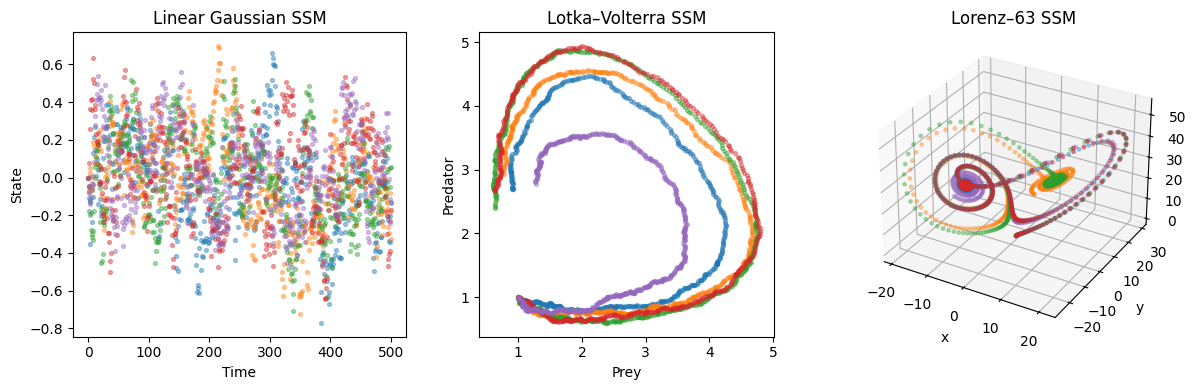

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Parameters
# -----------------------------
T = 500
n_realizations = 5
np.random.seed(123)

# -----------------------------
# Models
# -----------------------------
lgssm = LinearGaussianSSM(
    m0=np.array([0.0]),
    P0=np.array([[0.1]]),
    A=np.array([[0.9]]),
    H=np.array([[0.1]]),
    Sigma=0.01 * np.eye(1),
    Gamma=0.5 * np.eye(1),
)

lvssm = LotkaVolterraSSM()
lorenzssm = Lorenz63SSM()

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

# -----------------------------
# Linear Gaussian SSM (scatter in time)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lgssm.simulate(T)
    ax1.scatter(
        np.arange(T + 1),
        X[:, 0],
        s=8,
        alpha=0.4
    )

ax1.set_title("Linear Gaussian SSM")
ax1.set_xlabel("Time")
ax1.set_ylabel("State")

# -----------------------------
# Lotka–Volterra (2D phase space)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lvssm.simulate(T)
    ax2.scatter(
        X[:, 0],
        X[:, 1],
        s=8,
        alpha=0.4
    )

ax2.set_title("Lotka–Volterra SSM")
ax2.set_xlabel("Prey")
ax2.set_ylabel("Predator")
ax2.set_aspect("equal")

# -----------------------------
# Lorenz–63 (3D attractor)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lorenzssm.simulate(T)
    ax3.scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        s=6,
        alpha=0.35
    )

ax3.set_title("Lorenz–63 SSM")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

plt.tight_layout()
plt.show()


## `BayesianFilter` class

In [ ]:

class BayesianFilter:
    """
    Bayesian filters in state space models.
    """

    def __init__(self, model, theta=None):
        self.model = model
        self.theta = theta

        self.m, self.P = model.prior()
        self.log_likelihood = 0.0

        self.history_m = []
        self.history_P = []
        self.history_ll = []
        self.history_particles = []
        self.history_weights = []


        

    def _store(self):
        self.history_m.append(None if self.m is None else self.m.copy())
        self.history_P.append(None if self.P is None else self.P.copy())
        self.history_ll.append(self.log_likelihood)

        self.history_particles.append(None)
        self.history_weights.append(None)


    def predict(self):
        raise NotImplementedError

    def update(self, y):
        raise NotImplementedError

    def filter(self, Y):
        self._store()

        for y in Y:
            self.predict()
            self.update(y)
            self._store()

        return {
            "filtering_mean": self.m,
            "filtering_cov": self.P,
            "particles": None,
            "weights": None,
            "log_likelihood": self.log_likelihood,
            "history": {
                "mean": self.history_m,
                "cov": self.history_P,
                "log_likelihood": self.history_ll,
                "particles": self.history_particles,
                "weights": self.history_weights,
            }
        }
    
    # History 
    def get_means(self):
        return np.array(self.history_m)

    def get_covariances(self):
        return np.array(self.history_P)

    def get_loglikelihood(self):
        return np.array(self.history_ll)
    
    def plot_state(self, dim=0, X_true=None, sigma=2.0):
        """
        Plot the component dim of the filter state.
        """
        m = self.get_means()
        P = self.get_covariances()

        t = np.arange(len(m))
        mean = m[:, dim]
        std = np.sqrt(P[:, dim, dim])

        plt.figure()
        plt.plot(t, mean, label="Filtered")
        plt.fill_between(
            t,
            mean - sigma * std,
            mean + sigma * std,
            alpha=0.3,
            label=f"±{sigma}σ"
        )

        if X_true is not None:
            plt.plot(t, X_true[1:, dim], "--", label="True")

        plt.xlabel("Time")
        plt.ylabel(f"State x[{dim}]")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    def plot_variance(self, dim=0):
        P = self.get_covariances()
        t = np.arange(len(P))

        plt.figure()
        plt.plot(t, P[:, dim, dim])
        plt.xlabel("Time")
        plt.ylabel(f"Var(x[{dim}])")
        plt.grid(True)
        plt.show()
    
    def plot_loglikelihood(self):
        ll = self.get_loglikelihood()

        plt.figure()
        plt.plot(ll)
        plt.xlabel("Time")
        plt.ylabel("Cumulative log-likelihood")
        plt.grid(True)
        plt.show()

    # Metrics

    def rmse(self, X_true):
        """
        RMSE per time.
        """
        m = self.get_means()
        err = m - X_true[1:]
        return np.sqrt(np.mean(err**2, axis=1))
    
    def rmse_total(self, X_true):
        rmse_t = self.rmse(X_true)
        return np.mean(rmse_t)
    
    def mae(self, X_true):
        m = self.get_means()    
        return np.mean(np.abs(m - X_true[1:]), axis=1)

    def negative_log_likelihood(self):
        return -self.get_loglikelihood()
  
    def effective_sample_size(self):
        """
        ESS per time (only for PF).
        """
        ess = []

        for w in self.history_weights:
            if w is None:
                ess.append(np.nan)
            else:
                ess.append(1.0 / np.sum(w**2))

        return np.array(ess)
    
    def plot_ess(self):
        ess = self.effective_sample_size()

        plt.figure()
        plt.plot(ess)
        plt.xlabel("Tiempo")
        plt.ylabel("ESS")
        plt.grid(True)
        plt.show()

In [11]:

class KalmanFilter(BayesianFilter):
    """
    Kalman Filter / Extended Kalman Filter
    """

    @staticmethod
    def log_gaussian_density(y, mu, S):
        d = len(y)
        diff = y - mu
        try:
            c, lower = linalg.cho_factor(S, check_finite=False)
            alpha = linalg.cho_solve((c, lower), diff)
            logdet = 2 * np.sum(np.log(np.diag(c)))
        except np.linalg.LinAlgError:
            alpha = np.linalg.solve(S, diff)
            logdet = np.log(np.linalg.det(S))

        return -0.5 * (diff @ alpha + logdet + d * np.log(2 * np.pi))

    def predict(self):
        F = self.model.f_x(self.m, self.theta)
        Q = self.model.Q(self.m, self.theta)

        self.m_minus = self.model.f(self.m, self.theta)
        self.P_minus = F @ self.P @ F.T + Q

    def update(self, y):
        H = self.model.h_x(self.m_minus, self.theta)
        R = self.model.R(self.m_minus, self.theta)

        mu = self.model.h(self.m_minus, self.theta)
        S = H @ self.P_minus @ H.T + R

        self.log_likelihood += self.log_gaussian_density(y, mu, S)

        try:
            c, lower = linalg.cho_factor(S, check_finite=False)
            S_inv = linalg.cho_solve((c, lower), np.eye(S.shape[0]))
        except np.linalg.LinAlgError:
            S_inv = np.linalg.inv(S)

        K = self.P_minus @ H.T @ S_inv
        innovation = y - mu

        self.m = self.m_minus + K @ innovation
        self.P = self.P_minus - K @ H @ self.P_minus

        # estabilidad numérica
        self.P = 0.5 * (self.P + self.P.T)
        self.P += 1e-8 * np.eye(self.P.shape[0])

In [12]:
class UnscentedKalmanFilter(BayesianFilter):
    """
    Unscented Kalman Filter for StateSpaceModel
    """

    def __init__(self, model, theta=None,
                 alpha=1e-3, beta=2.0, kappa=0.0):

        super().__init__(model, theta)

        self.d = model.d
        self.m_obs = model.m

        # parameters UKF
        self.alpha = alpha
        self.beta = beta
        self.kappa = kappa

        self.lambd = alpha**2 * (self.d + kappa) - self.d
        self.denom = self.d + self.lambd
        self.sqrt_d_lamb = np.sqrt(self.denom)

        self.w0m = self.lambd / self.denom
        self.w0c = self.w0m + (1.0 - alpha**2 + beta)
        self.wim = 1.0 / (2.0 * self.denom)

    # --------------------------------------------------
    @staticmethod
    def log_gaussian_density(y, mu, S):
        d = len(y)
        diff = y - mu
        try:
            c, lower = linalg.cho_factor(S, check_finite=False)
            alpha = linalg.cho_solve((c, lower), diff)
            logdet = 2 * np.sum(np.log(np.diag(c)))
        except np.linalg.LinAlgError:
            alpha = np.linalg.solve(S, diff)
            logdet = np.log(np.linalg.det(S))

        return -0.5 * (diff @ alpha + logdet + d * np.log(2 * np.pi))

    # --------------------------------------------------
    def _sigma_points(self, m, P):
        try:
            A = np.linalg.cholesky(P)
        except np.linalg.LinAlgError:
            A = np.linalg.cholesky(P + 1e-8 * np.eye(self.d))

        X = np.empty((self.d, 2 * self.d + 1))
        X[:, 0] = m

        for i in range(self.d):
            col = A[:, i]
            X[:, 1 + i] = m + self.sqrt_d_lamb * col
            X[:, 1 + self.d + i] = m - self.sqrt_d_lamb * col

        return X

    # --------------------------------------------------
    def predict(self):
        X = self._sigma_points(self.m, self.P)

        X_hat = np.zeros_like(X)
        for i in range(2 * self.d + 1):
            X_hat[:, i] = self.model.f(X[:, i], self.theta)

        m_minus = (
            self.w0m * X_hat[:, 0]
            + self.wim * np.sum(X_hat[:, 1:], axis=1)
        )

        P_minus = self.model.Q(m_minus, self.theta).astype(float)
        for i in range(2 * self.d + 1):
            diff = X_hat[:, i] - m_minus
            w = self.w0c if i == 0 else self.wim
            P_minus += w * np.outer(diff, diff)

        self.m_minus = m_minus
        self.P_minus = 0.5 * (P_minus + P_minus.T)

    # --------------------------------------------------
    def update(self, y):
        X = self._sigma_points(self.m_minus, self.P_minus)

        Y_hat = np.zeros((self.m_obs, 2 * self.d + 1))
        for i in range(2 * self.d + 1):
            Y_hat[:, i] = self.model.h(X[:, i], self.theta)

        mu = (
            self.w0m * Y_hat[:, 0]
            + self.wim * np.sum(Y_hat[:, 1:], axis=1)
        )

        S = self.model.R(self.m_minus, self.theta).astype(float)
        for i in range(2 * self.d + 1):
            dy = Y_hat[:, i] - mu
            w = self.w0c if i == 0 else self.wim
            S += w * np.outer(dy, dy)

        S = 0.5 * (S + S.T)

        self.log_likelihood += self.log_gaussian_density(y, mu, S)

        C = np.zeros((self.d, self.m_obs))
        for i in range(2 * self.d + 1):
            dx = X[:, i] - self.m_minus
            dy = Y_hat[:, i] - mu
            w = self.w0c if i == 0 else self.wim
            C += w * np.outer(dx, dy)

        try:
            cho = np.linalg.cholesky(S)
            K = linalg.cho_solve((cho, True), C.T).T
        except np.linalg.LinAlgError:
            K = C @ np.linalg.inv(S)

        self.m = self.m_minus + K @ (y - mu)
        self.P = self.P_minus - K @ C.T
        self.P = 0.5 * (self.P + self.P.T)
        

In [13]:

class ParticleFilter(BayesianFilter):
    """
    Particle Filter for StateSpaceModel
    """

    def __init__(self, model, N, theta=None, resample_threshold=0.15):
        super().__init__(model, theta)

        self.N = N
        self.resample_threshold = resample_threshold

        self.d = model.d
        self.m_obs = model.m

        # inicialization of particules from prior
        m0, P0 = model.prior()
        self.particles = np.random.multivariate_normal(
            mean=m0, cov=P0, size=N
        )

        self.logw = np.zeros(N) - np.log(N)

    # --------------------------------------------------
    def _store(self):
        self.history_m.append(self.m.copy())
        self.history_P.append(self.P.copy())
        self.history_ll.append(self.log_likelihood)

        self.history_particles.append(self.particles.copy())
        self.history_weights.append(np.exp(self.logw).copy())


    # --------------------------------------------------
    @staticmethod
    def log_gaussian_density(y, mu, S):
        d = len(y)
        diff = y - mu
        try:
            c = np.linalg.cholesky(S)
            alpha = np.linalg.solve(c.T, np.linalg.solve(c, diff))
            logdet = 2 * np.sum(np.log(np.diag(c)))
        except np.linalg.LinAlgError:
            alpha = np.linalg.solve(S, diff)
            logdet = np.log(np.linalg.det(S))

        return -0.5 * (diff @ alpha + logdet + d * np.log(2 * np.pi))

    # --------------------------------------------------
    def predict(self):
        for i in range(self.N):
            self.particles[i] = self.model.sample_transition(
                self.particles[i], self.theta
            )

    # --------------------------------------------------
    def update(self, y):
        logw_new = np.zeros(self.N)

        R = self.model.R(None, self.theta)

        for i in range(self.N):
            y_pred = self.model.h(self.particles[i], self.theta)
            logw_new[i] = self.logw[i] + self.log_gaussian_density(
                y, y_pred, R
            )

        # normalización estable
        logZ = logsumexp(logw_new)
        self.logw = logw_new - logZ
        self.log_likelihood += logZ

    # --------------------------------------------------
    def effective_sample_size(self):
        w = np.exp(self.logw)
        return 1.0 / np.sum(w**2)

    # --------------------------------------------------
    def resample(self):
        w = np.exp(self.logw)
        idx = np.random.choice(self.N, size=self.N, p=w)

        self.particles = self.particles[idx]
        self.logw[:] = -np.log(self.N)

    # --------------------------------------------------
    def estimate(self):
        w = np.exp(self.logw)

        mean = np.sum(self.particles * w[:, None], axis=0)

        diff = self.particles - mean
        cov = diff.T @ (diff * w[:, None])

        self.m = mean
        self.P = 0.5 * (cov + cov.T)

    # --------------------------------------------------
    def update_step(self, y):
        self.predict()
        self.update(y)

        if self.effective_sample_size() < self.resample_threshold * self.N:
            self.resample()

        self.estimate()

    #--------------------------------------------------

    def filter(self, Y):

        for y in Y:
            self.update_step(y)
            self._store()

        return {
            "filtering_mean": self.m,
            "filtering_cov": self.P,
            "particles": self.particles,
            "weights": np.exp(self.logw),
            "log_likelihood": self.log_likelihood,
            "history": {
                "mean": self.history_m,
                "cov": self.history_P,
                "log_likelihood": self.history_ll,
                "particles": self.history_particles,
                "weights": self.history_weights
            }
        }

In [14]:
class UKFWithPFRestart(BayesianFilter):
    """
    UKF with periodic PF-based correction (block-wise restart).
    """

    def __init__(
        self,
        model,
        L,
        N,
        theta=None,
        alpha=1e-3,
        beta=2.0,
        kappa=0.0,
        pf_resample_threshold=0.15,
    ):
        super().__init__(model, theta)

        self.L = L
        self.N = N
        self.t = 0  # contador global

        # UKF interno
        self.ukf = UnscentedKalmanFilter(
            model,
            theta=theta,
            alpha=alpha,
            beta=beta,
            kappa=kappa,
        )

        # sincronizar estado inicial
        self.ukf.m = self.m.copy()
        self.ukf.P = self.P.copy()

        self.pf_resample_threshold = pf_resample_threshold

    # --------------------------------------------------
    def predict(self):
        self.ukf.predict()

    # --------------------------------------------------
    def update(self, y):
        self.ukf.update(y)

        # copiar estado UKF
        self.m = self.ukf.m.copy()
        self.P = self.ukf.P.copy()
        self.log_likelihood = self.ukf.log_likelihood

        self.t += 1

        # ¿checkpoint?
        if self.t % self.L == 0:
            self._pf_correction(y)

    # --------------------------------------------------
    def _pf_correction(self, y_last):
        """
        Run a short PF initialized from the current Gaussian posterior.
        """

        # Inicializar PF desde la Gaussiana actual
        pf = ParticleFilter(
            self.model,
            N=self.N,
            theta=self.theta,
            resample_threshold=self.pf_resample_threshold,
        )

        pf.particles = np.random.multivariate_normal(
            mean=self.m,
            cov=self.P,
            size=self.N,
        )
        pf.logw[:] = -np.log(self.N)

        # correr PF SOLO un paso (o varios si querés extender)
        pf.update(y_last)
        pf.estimate()

        # proyectar PF → Gaussiana
        self.m = pf.m.copy()
        self.P = pf.P.copy()

        # reiniciar UKF con el posterior corregido
        self.ukf.m = self.m.copy()
        self.ukf.P = self.P.copy()

        # guardar partículas solo en checkpoint
        self.history_particles[-1] = pf.particles.copy()
        self.history_weights[-1] = np.exp(pf.logw).copy()


## Experiments

In [15]:

def run_experiment(model, T, L_r = 10, pf_particles=20000, print_results=True):
    # Simulación
    X_true, Y = model.simulate(T)

    # Filtros
    kf = KalmanFilter(model)
    ukf = UnscentedKalmanFilter(model)
    pf = ParticleFilter(model, N=pf_particles)
    bf = UKFWithPFRestart(model, L= L_r, N=pf_particles)

    # KF
    t0 = time.time()
    res_kf = kf.filter(Y)
    kf_time = time.time() - t0

    # UKF
    t0 = time.time()
    res_ukf = ukf.filter(Y)
    ukf_time = time.time() - t0

    # PF
    t0 = time.time()
    res_pf = pf.filter(Y)
    pf_time = time.time() - t0

    # UKF + PF
    t0 = time.time()
    res_bf = bf.filter(Y)
    bf_time = time.time() - t0

    def rmse(x_hat, x_true):
        return np.sqrt(np.mean((x_hat - x_true)**2))

    results = {
        "KF": {
            "rmse": rmse(res_kf["filtering_mean"], X_true[-1]),
            "logL": res_kf["log_likelihood"],
            "time": kf_time,
        },
        "UKF": {
            "rmse": rmse(res_ukf["filtering_mean"], X_true[-1]),
            "logL": res_ukf["log_likelihood"],
            "time": ukf_time,
        },
        "PF": {
            "rmse": rmse(res_pf["filtering_mean"], X_true[-1]),
            "logL": res_pf["log_likelihood"],
            "time": pf_time,
        },
        "BF": {
            "rmse": rmse(res_bf["filtering_mean"], X_true[-1]),
            "logL": res_bf["log_likelihood"],
            "time": bf_time,
        },
        "X_true": X_true,
        "Y": Y,
        "results": {
            "KF": res_kf,
            "UKF": res_ukf,
            "PF": res_pf,
            "BF": res_bf,
        }
    }
    
    if print_results:

        print(f"KF  | RMSE: {results['KF']['rmse']:.5f} | logL: {results['KF']['logL']:.5f} | time: {kf_time:.3f}s")
        print(f"UKF | RMSE: {results['UKF']['rmse']:.5f} | logL: {results['UKF']['logL']:.5f} | time: {ukf_time:.3f}s")
        print(f"PF  | RMSE: {results['PF']['rmse']:.5f} | logL: {results['PF']['logL']:.5f} | time: {pf_time:.3f}s")
        print(f"BF  | RMSE: {results['BF']['rmse']:.5f} | logL: {results['BF']['logL']:.5f} | time: {bf_time:.3f}s")


    return results



### Linear-Gaussian model

In [9]:
A = np.array([[1.0, 0.1],
              [0.0, 1.0]])
H = np.array([[1.0, 0.0]])
Sigma = 0.001 * np.eye(2)
Gamma = 0.01 * np.eye(1)
m0 = np.zeros(2)
P0 = np.eye(2)

model = LinearGaussianSSM(
    m0=m0,
    P0=P0,
    A=A,
    H=H,
    Sigma=Sigma,
    Gamma=Gamma
)

kf = KalmanFilter(model)
ukf = UnscentedKalmanFilter(model)
pf = ParticleFilter(model, N=20000)
bf = UKFWithPFRestart(model, L=10, N=20000)


X_true, Y = model.simulate(T=100)

import time

t0 = time.time()
res_kf = kf.filter(Y)
kf_time = time.time() - t0

t0 = time.time()
res_ukf = ukf.filter(Y)
ukf_time = time.time() - t0

t0 = time.time()
res_pf = pf.filter(Y)
pf_time = time.time() - t0

t0 = time.time()
res_bf = bf.filter(Y)
bf_time = time.time() - t0



def rmse(x_hat, x_true):
    return np.sqrt(np.mean((x_hat - x_true)**2))

kf_rmse = rmse(res_kf["filtering_mean"][0], X_true[-1])
ukf_rmse = rmse(res_ukf["filtering_mean"][0], X_true[-1])
pf_rmse = rmse(res_pf["filtering_mean"][0], X_true[-1])
bf_rmse = rmse(res_bf["filtering_mean"][0], X_true[-1])

kf_ll = res_kf["log_likelihood"]
ukf_ll = res_ukf["log_likelihood"]
pf_ll = res_pf["log_likelihood"]
bf_ll = res_bf["log_likelihood"]

print("\n=== Linear Gaussian model - Comparison of filters ===\n")

print(f"KF  | RMSE: {kf_rmse:.5f} | logL: {kf_ll:.5f} | time: {kf_time:.3f}s")
print(f"UKF | RMSE: {ukf_rmse:.5f} | logL: {ukf_ll:.5f} | time: {ukf_time:.3f}s")
print(f"PF  | RMSE: {pf_rmse:.5f} | logL: {pf_ll:.5f} | time: {pf_time:.3f}s")
print(f"BF  | RMSE: {bf_rmse:.5f} | logL: {bf_ll:.5f} | time: {bf_time:.3f}s")




=== Linear Gaussian model - Comparison of filters ===

KF  | RMSE: 0.39139 | logL: 70.48873 | time: 0.012s
UKF | RMSE: 0.39139 | logL: 70.48875 | time: 0.048s
PF  | RMSE: 0.39174 | logL: 70.42164 | time: 290.138s
BF  | RMSE: 0.38694 | logL: 69.70050 | time: 8.922s


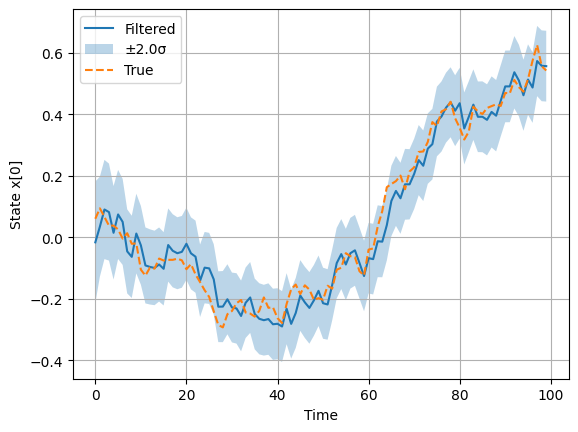

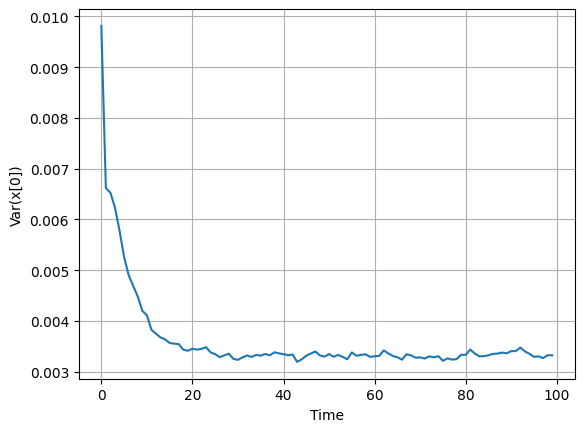

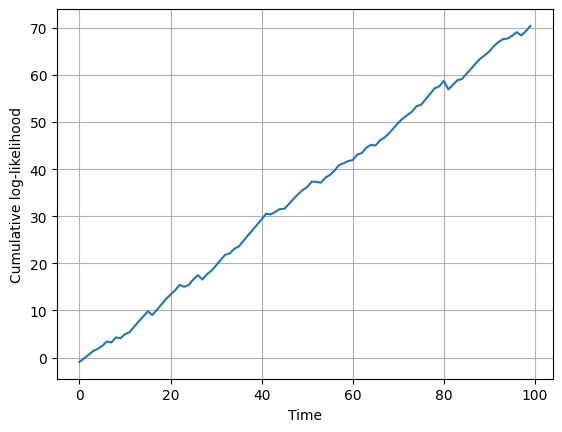

RMSE total: 0.07374432794874228


In [10]:
pf.plot_state(dim=0, X_true=X_true)
pf.plot_variance(dim=0)
pf.plot_loglikelihood()

print("RMSE total:", pf.rmse_total(X_true))

### Lokta-Volterra model

In [11]:

model_lv = LotkaVolterraSSM(
    alpha=1.5,
    beta=1.0,
    delta=1.0,
    gamma=3.0,
    dt=0.1,
    m0=np.array([1.0, 0.5]),
    P0=0.5 * np.eye(2),
    Sigma=0.01 * np.eye(2),
    Gamma=0.5 * np.eye(2),
    H=np.array([[1.0, 0.0],[0.0, 0.0]])
)

res_lv = run_experiment(model_lv, T=25, L_r = 5, pf_particles=50000)


KF  | RMSE: 0.34286 | logL: -72.16836 | time: 0.005s
UKF | RMSE: 0.35663 | logL: -72.17942 | time: 0.008s
PF  | RMSE: 0.36277 | logL: -72.49075 | time: 212.841s
BF  | RMSE: 0.51966 | logL: -72.61579 | time: 11.316s


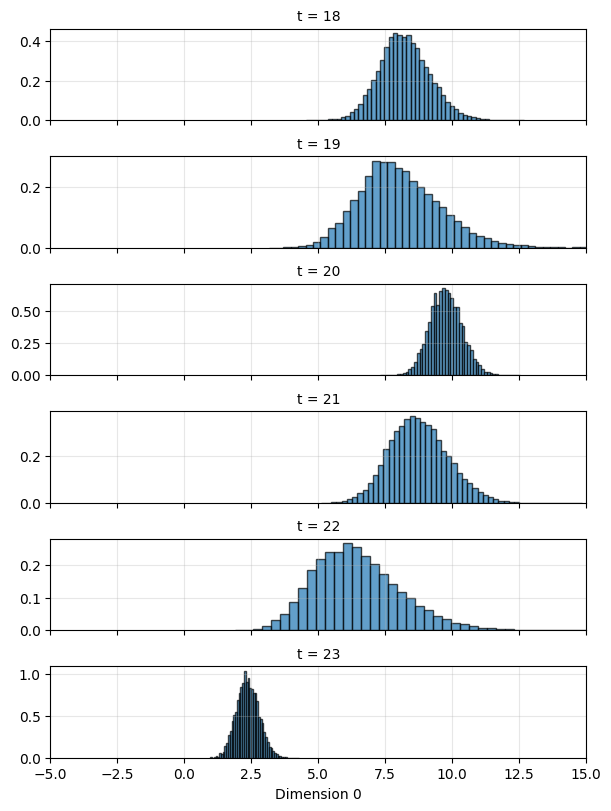

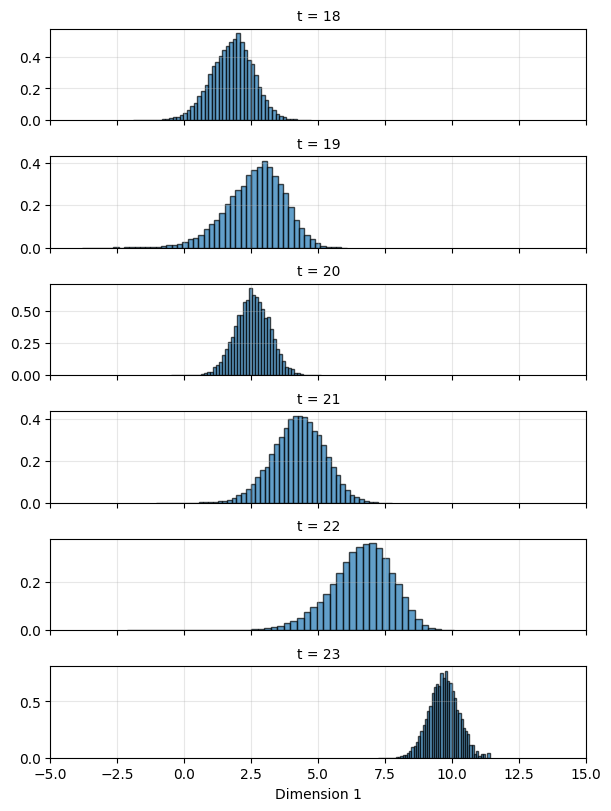

In [12]:

T_v = 18
dim = 0
lims = (-5, 15)

particles = np.array(res_lv['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

########################


dim = 1

particles = np.array(res_lv['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

del T_v, dim, lims, particles, fig, axes

### Lorenz 63' model

In [13]:
model_l63 = Lorenz63SSM(
    sigma=10.0,
    rho=28.0,
    beta=8/3,
    dt=0.0285,
    m0=np.array([1.0, 1.0, 1.0]),
    P0=0.01 * np.eye(3),
    Sigma=0.1 * np.eye(3),
    Gamma=0.1 * np.eye(3), 
    H=np.array([[0.0, 0.0, 0.0],[1.0, 0.0, 1.0],[0.0, 0.0, 1.0]])
)

res_l63 = run_experiment(model_l63, T=30, L_r = 5, pf_particles=25000)


KF  | RMSE: 0.25554 | logL: -62.80899 | time: 0.005s
UKF | RMSE: 0.25691 | logL: -62.81106 | time: 0.014s
PF  | RMSE: 0.24540 | logL: -63.00237 | time: 117.632s
BF  | RMSE: 0.24848 | logL: -63.25831 | time: 6.766s


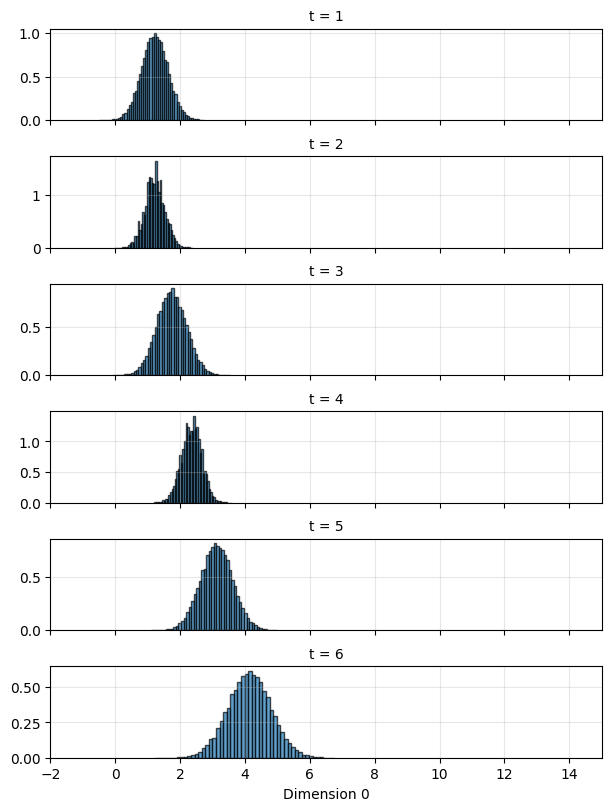

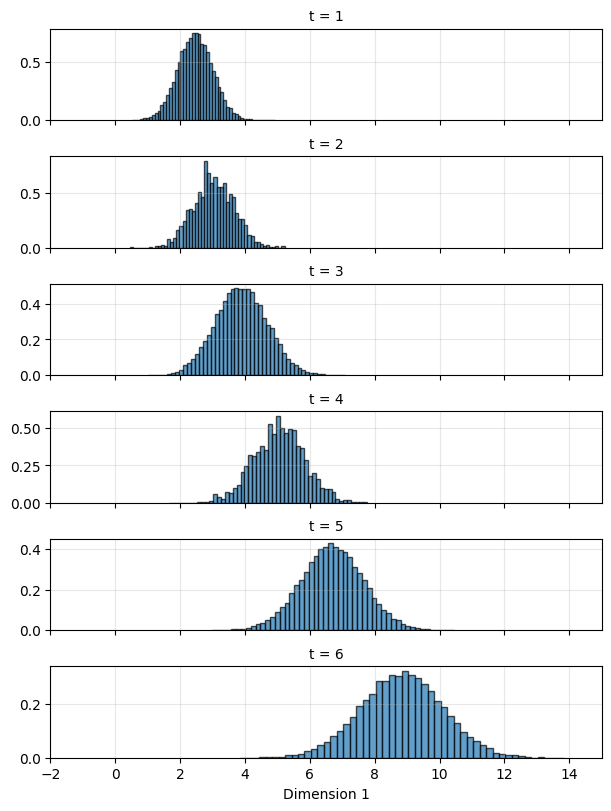

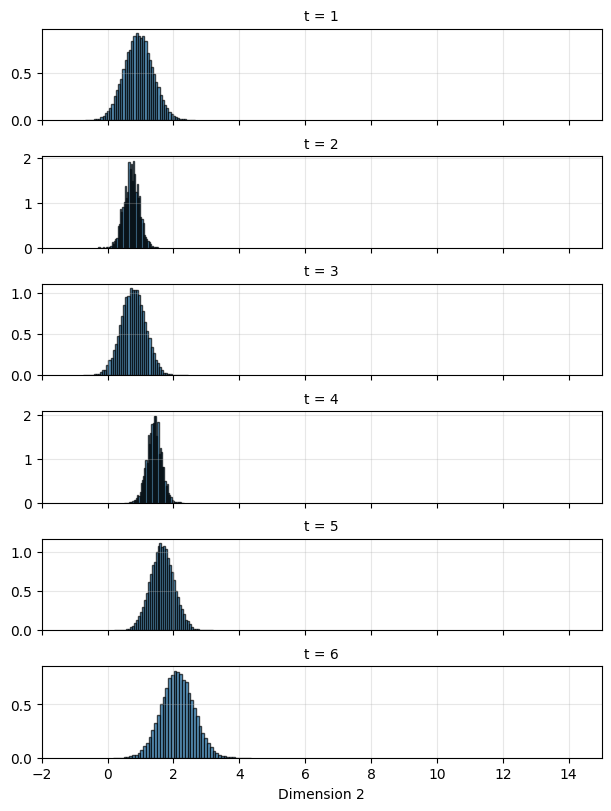

In [14]:

T_v = 1
dim = 0
lims = (-2, 15)

particles = np.array(res_l63['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

########################
dim = 1

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()


########################
dim = 2

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

del T_v, dim, lims, particles, fig, axes

# Numerical experiments

## Drift

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.linalg import sqrtm
from scipy.stats import wasserstein_distance

np.random.seed(42)  # reproducibility


Drift metrics (mean-based)

In [20]:
def euclidean_drift(m_gauss, m_pf):
    """
    Euclidean drift between Gaussian filter and PF means.
    """
    return np.linalg.norm(m_gauss - m_pf)


def mahalanobis_drift(m_gauss, m_pf, P_pf):
    """
    Mahalanobis drift using PF covariance as reference metric.
    """
    diff = m_gauss - m_pf
    try:
        invP = np.linalg.inv(P_pf)
    except np.linalg.LinAlgError:
        invP = np.linalg.pinv(P_pf)

    return np.sqrt(diff.T @ invP @ diff)


Closed-form Wasserstein distance (Gaussian vs Gaussian)

In [21]:
def wasserstein_2_gaussian(m1, P1, m2, P2):
    """
    Closed-form Wasserstein-2 distance between two Gaussian distributions.
    """
    mean_term = np.linalg.norm(m1 - m2)**2

    # symmetric sqrt
    sqrtP2 = sqrtm(P2)
    middle = sqrtm(sqrtP2 @ P1 @ sqrtP2)

    trace_term = np.trace(P1 + P2 - 2 * middle)

    return np.sqrt(np.real(mean_term + trace_term))


In [22]:
def wasserstein_1_particles_vs_gaussian(particles, m_gauss):
    """
    Approximate W1 using marginal 1D Wasserstein per dimension.
    """
    d = particles.shape[1]
    w1 = 0.0

    for i in range(d):
        w1 += wasserstein_distance(
            particles[:, i],
            np.random.normal(m_gauss[i], 1e-6, size=len(particles))
        )

    return w1


Single-run drift experiment

In [23]:
def single_drift_run(
    model,
    T=500,
    N_pf_gt=20000,   # high fidelity PF
    N_pf_ref=5000    # regular PF for comparison
):
    """
    Run one simulation and compute drift metrics.
    """

    # Simulate data
    X_true, Y = model.simulate(T)

    # High-fidelity PF (ground truth)
    pf_gt = ParticleFilter(model, N=N_pf_gt)
    pf_gt.filter(Y)

    # UKF
    ukf = UnscentedKalmanFilter(model)
    ukf.filter(Y)

    # Extract histories
    m_pf = np.array(pf_gt.history_m)
    P_pf = np.array(pf_gt.history_P)

    m_ukf = np.array(ukf.history_m)
    P_ukf = np.array(ukf.history_P)

    drift_euc = []
    drift_maha = []
    drift_w2 = []

    for k in range(len(m_pf)):
        d_e = euclidean_drift(m_ukf[k], m_pf[k])
        d_m = mahalanobis_drift(m_ukf[k], m_pf[k], P_pf[k])
        d_w2 = wasserstein_2_gaussian(
            m_ukf[k], P_ukf[k],
            m_pf[k], P_pf[k]
        )

        drift_euc.append(d_e)
        drift_maha.append(d_m)
        drift_w2.append(d_w2)

    return {
        "drift_euclidean": np.array(drift_euc),
        "drift_mahalanobis": np.array(drift_maha),
        "drift_w2": np.array(drift_w2),
        "X_true": X_true,
        "ukf": ukf,
        "pf_gt": pf_gt
    }


Drift time detection

In [24]:
def drift_time(drift_norm, threshold=3.0):
    """
    Return first time index where normalized drift exceeds threshold.
    """
    idx = np.where(drift_norm > threshold)[0]
    if len(idx) == 0:
        return np.nan
    return idx[0]


Monte Carlo experiment

In [25]:
def monte_carlo_drift(
    model,
    R=10,
    T=500,
    threshold=3.0
):
    """
    Monte Carlo experiment for drift statistics.
    """

    drift_times = []
    max_w2 = []
    cumulative_w2 = []

    for r in range(R):
        print(f"Run {r+1}/{R}")

        out = single_drift_run(model, T=T)

        tau = drift_time(
            out["drift_mahalanobis"],
            threshold=threshold
        )

        drift_times.append(tau)
        max_w2.append(np.max(out["drift_w2"]))
        cumulative_w2.append(np.sum(out["drift_w2"]))

    return {
        "drift_times": np.array(drift_times),
        "max_w2": np.array(max_w2),
        "cumulative_w2": np.array(cumulative_w2)
    }


Example execution (Lotka–Volterra)

In [27]:
model = LotkaVolterraSSM(
    dt=0.02,
    Sigma=1e-4 * np.eye(2),
    Gamma=5e-2 * np.eye(2)
)

results = monte_carlo_drift(
    model,
    R=5,
    T=30,
    threshold=3.0
)

print("Median drift time:",
      np.nanmedian(results["drift_times"]))

print("Probability of drift:",
      np.mean(~np.isnan(results["drift_times"])))

print("Median max W2:",
      np.median(results["max_w2"]))


Run 1/5
Run 2/5
Run 3/5
Run 4/5
Run 5/5
Median drift time: nan
Probability of drift: 0.0
Median max W2: 0.06920854103629734


C:\Users\carlo\AppData\Local\Temp\ipykernel_12804\3851982743.py:15: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(results["drift_times"]))


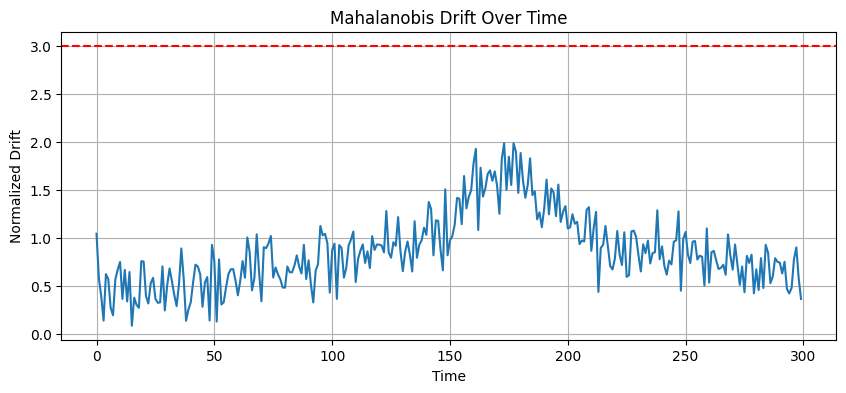

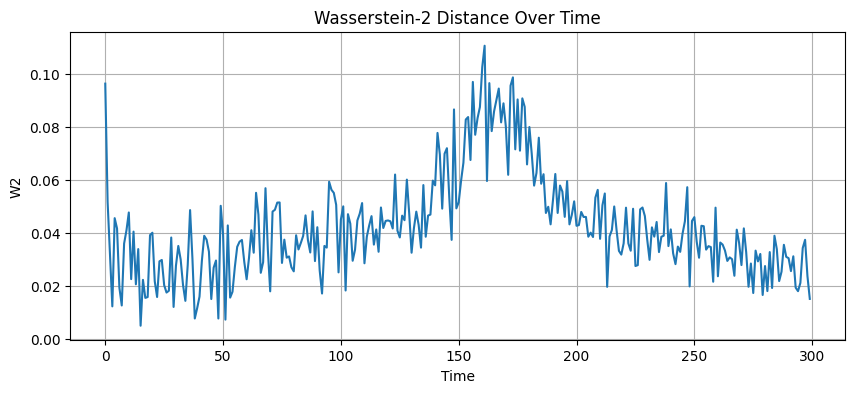

In [31]:
out = single_drift_run(model, T=300)

plt.figure(figsize=(10,4))
plt.plot(out["drift_mahalanobis"])
plt.axhline(3.0, color="red", linestyle="--")
plt.title("Mahalanobis Drift Over Time")
plt.xlabel("Time")
plt.ylabel("Normalized Drift")
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.plot(out["drift_w2"])
plt.title("Wasserstein-2 Distance Over Time")
plt.xlabel("Time")
plt.ylabel("W2")
plt.grid(True)
plt.show()


## How to choose the number of particles and the checkpoints?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import itertools
import pandas as pd

np.random.seed(123)


In [ ]:
def evaluate_configuration(
    model,
    L,
    N,
    Y,
    X_true,
    R=5
):
    """
    Evaluate one (L, N) configuration over R Monte Carlo runs.
    Returns aggregated metrics.
    """

    rmse_list = []
    mae_list = []
    ll_list = []
    time_list = []

    for r in range(R):

        # reinitialize model prior for each repetition
        filter_instance = UKFWithPFRestart(
            model,
            L=L,
            N=N
        )

        start = time.perf_counter()
        filter_instance.filter(Y)
        end = time.perf_counter()

        elapsed = end - start

        rmse_val = filter_instance.rmse_total(X_true)
        mae_val = np.mean(filter_instance.mae(X_true))
        ll_val = filter_instance.get_loglikelihood()[-1]

        rmse_list.append(rmse_val)
        mae_list.append(mae_val)
        ll_list.append(ll_val)
        time_list.append(elapsed)

    rmse_mean = np.mean(rmse_list)
    rmse_var = np.var(rmse_list)
    mae_mean = np.mean(mae_list)
    ll_mean = np.mean(ll_list)
    time_mean = np.mean(time_list)

    efficiency = rmse_mean / time_mean

    return {
        "L": L,
        "N": N,
        "RMSE": rmse_mean,
        "RMSE_var": rmse_var,
        "MAE": mae_mean,
        "LogLik": ll_mean,
        "Time": time_mean,
        "Efficiency": efficiency
    }


In [ ]:
def hyperparameter_grid_experiment(
    model,
    T=300,
    L_values=[5,10,20,40],
    N_values=[500,1000,5000,10000],
    R=3
):
    """
    Full grid experiment.
    """

    # Simulate dataset ONCE (same dataset for fairness)
    X_true, Y = model.simulate(T)

    results = []

    for L, N in itertools.product(L_values, N_values):

        print(f"Evaluating L={L}, N={N}")

        metrics = evaluate_configuration(
            model=model,
            L=L,
            N=N,
            Y=Y,
            X_true=X_true,
            R=R
        )

        results.append(metrics)

    df = pd.DataFrame(results)

    return df


In [ ]:
model = LotkaVolterraSSM(
    dt=0.02,
    Sigma=1e-4 * np.eye(2),
    Gamma=5e-2 * np.eye(2)
)

df_results = hyperparameter_grid_experiment(
    model,
    T=300,
    R=3
)

print(df_results)


In [ ]:
def plot_heatmap(df, metric_name):

    pivot = df.pivot(index="L", columns="N", values=metric_name)

    plt.figure(figsize=(6,5))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=metric_name)

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.xlabel("N (Particles)")
    plt.ylabel("L (Checkpoint interval)")
    plt.title(f"{metric_name} Heatmap")
    plt.show()


plot_heatmap(df_results, "RMSE")
plot_heatmap(df_results, "Time")
plot_heatmap(df_results, "Efficiency")


In [ ]:
def plot_pareto(df):

    plt.figure(figsize=(6,5))

    for _, row in df.iterrows():
        plt.scatter(row["Time"], row["RMSE"])
        plt.text(row["Time"], row["RMSE"],
                 f"L={row['L']},N={row['N']}",
                 fontsize=8)

    plt.xlabel("Time")
    plt.ylabel("RMSE")
    plt.title("Pareto Frontier: Accuracy vs Cost")
    plt.grid(True)
    plt.show()


plot_pareto(df_results)


In [ ]:
best_idx = df_results["Efficiency"].idxmin()
best_config = df_results.loc[best_idx]

print("Recommended configuration:")
print(best_config)


## Comparison proposed vs classic

In [ ]:
from scipy.stats import norm
from scipy.stats import wilcoxon
import pandas as pd

def crps_gaussian(mu, sigma, x):
    """
    Closed-form CRPS for 1D Gaussian.
    """
    z = (x - mu) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) +
                    2 * norm.pdf(z) -
                    1 / np.sqrt(np.pi))


In [ ]:
def crps_multivariate(mean, cov, x_true):
    """
    Average marginal CRPS across dimensions.
    """
    d = len(mean)
    score = 0.0
    for i in range(d):
        sigma = np.sqrt(cov[i, i])
        score += crps_gaussian(mean[i], sigma, x_true[i])
    return score / d


In [ ]:
def run_multiple_experiments_enhanced(
    model,
    T,
    n_iter=30,
    L_r=10,
    pf_particles=5000,
    print_table=True,
    plot_box=True
):
    """
    Enhanced method comparison experiment.
    """

    methods = ["KF", "UKF", "PF", "BF"]
    metrics = ["rmse", "mae", "logL", "crps", "time", "ess", "ess_per_sec"]

    stats = {
        m: {k: [] for k in metrics}
        for m in methods
    }

    for i in tqdm(range(n_iter), desc="Monte Carlo", unit="run"):

        results = run_experiment(
            model,
            T,
            L_r=L_r,
            pf_particles=pf_particles,
            print_results=False
        )

        X_true = results["X_true"]
        final_state = X_true[-1]

        for m in methods:

            res = results["results"][m]

            mean = res["filtering_mean"]
            cov = res["filtering_cov"]

            rmse_val = np.sqrt(np.mean((mean - final_state)**2))
            mae_val = np.mean(np.abs(mean - final_state))
            logL_val = res["logL"]

            crps_val = crps_multivariate(mean, cov, final_state)

            time_val = results[m]["time"]

            if m == "PF":
                ess_val = np.mean(results[m]["ess"])
            else:
                ess_val = np.nan

            ess_per_sec = ess_val / time_val if not np.isnan(ess_val) else np.nan

            stats[m]["rmse"].append(rmse_val)
            stats[m]["mae"].append(mae_val)
            stats[m]["logL"].append(logL_val)
            stats[m]["crps"].append(crps_val)
            stats[m]["time"].append(time_val)
            stats[m]["ess"].append(ess_val)
            stats[m]["ess_per_sec"].append(ess_per_sec)

    # Convert to numpy arrays
    for m in methods:
        for k in metrics:
            stats[m][k] = np.array(stats[m][k])

    # ======================================================
    # Summary table
    # ======================================================
    if print_table:

        print("\nStatistical summary (mean ± std)\n")

        header = (
            f"{'Method':<6} | {'RMSE':<15} | {'CRPS':<15} | "
            f"{'logL':<15} | {'Time':<10}"
        )
        print(header)
        print("-" * len(header))

        for m in methods:
            print(
                f"{m:<6} | "
                f"{stats[m]['rmse'].mean():.4f} ± {stats[m]['rmse'].std():.4f} | "
                f"{stats[m]['crps'].mean():.4f} ± {stats[m]['crps'].std():.4f} | "
                f"{stats[m]['logL'].mean():.2f} ± {stats[m]['logL'].std():.2f} | "
                f"{stats[m]['time'].mean():.3f}"
            )

    # ======================================================
    # Boxplots
    # ======================================================
    if plot_box:
        for metric in ["rmse", "crps", "time"]:
            plt.figure(figsize=(6,4))
            data = [stats[m][metric] for m in methods]
            plt.boxplot(data, tick_labels=methods)
            plt.title(metric.upper())
            plt.grid(alpha=0.3)
            plt.show()

    return stats


In [ ]:
from scipy.stats import t

def bayesian_method_comparison(stats, metric="rmse", baseline="BF"):
    """
    Fully Bayesian comparison between methods.
    Computes posterior probability that BF is better.
    """

    methods = list(stats.keys())

    print(f"\nBayesian comparison using metric: {metric.upper()}\n")

    for m in methods:

        if m == baseline:
            continue

        # Paired differences
        delta = stats[baseline][metric] - stats[m][metric]

        n = len(delta)
        mean_delta = np.mean(delta)
        std_delta = np.std(delta, ddof=1)

        # Posterior for mean under normal model with unknown variance
        # Using Student-t posterior

        se = std_delta / np.sqrt(n)
        df = n - 1

        # Probability that BF is better (delta < 0)
        prob = t.cdf(0, df=df, loc=mean_delta, scale=se)

        # 95% credible interval
        ci_low = mean_delta - t.ppf(0.975, df) * se
        ci_high = mean_delta + t.ppf(0.975, df) * se

        print(f"{baseline} vs {m}:")
        print(f"  Mean difference = {mean_delta:.6f}")
        print(f"  95% credible interval = [{ci_low:.6f}, {ci_high:.6f}]")
        print(f"  P({baseline} better than {m}) = {prob:.4f}\n")


In [ ]:
def bayesian_ranking(stats, metric="rmse"):

    methods = list(stats.keys())
    scores = {m: 0.0 for m in methods}

    for m1 in methods:
        for m2 in methods:
            if m1 == m2:
                continue

            delta = stats[m1][metric] - stats[m2][metric]
            prob = np.mean(delta < 0)
            scores[m1] += prob

    print("\nBayesian ranking (higher = better):")
    for m in sorted(scores, key=scores.get, reverse=True):
        print(m, "score =", scores[m])


In [ ]:
stats_lv = run_multiple_experiments_enhanced(
    model=model_lv,
    T=100,
    n_iter=30,
    L_r=4,
    pf_particles=5000
)

bayesian_method_comparison(stats_lv, metric="rmse")
bayesian_method_comparison(stats_lv, metric="crps")

bayesian_ranking(stats_lv, metric="rmse")
